# Libraries

In [ ]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt

# Reading Data

In [ ]:
data = pd.read_csv('C://University//Grad!!!!!!!!!//Data collection//Cleaning//Data//emg_streamed_cleaned_2.csv')
data.head()

,session_id,level_number,filtered_values,envelope_values
0,82,7,"[505.6666666666667, 505.6666666666667, 505.666...","[28.333333333333332, 28.333333333333332, 28.33..."
1,82,1,"[505.6666666666667, 505.6666666666667, 505.666...","[28.333333333333332, 28.333333333333332, 28.33..."
2,82,2,"[477.3333333333333, 496.3333333333333, 534.666...","[524.0, 514.3333333333334, 512.3333333333334, ..."
3,82,3,"[495.6666666666667, 495.6666666666667, 495.666...","[80.66666666666667, 67.0, 58.666666666666664, ..."
4,82,4,"[481.0, 474.6666666666667, 505.6666666666667, ...","[116.66666666666667, 116.66666666666667, 116.6..."


# Cleaning

Dropping id column

In [ ]:
data = data.drop("session_id", axis=1)
data.head()

,level_number,filtered_values,envelope_values
0,7,"[505.6666666666667, 505.6666666666667, 505.666...","[28.333333333333332, 28.333333333333332, 28.33..."
1,1,"[505.6666666666667, 505.6666666666667, 505.666...","[28.333333333333332, 28.333333333333332, 28.33..."
2,2,"[477.3333333333333, 496.3333333333333, 534.666...","[524.0, 514.3333333333334, 512.3333333333334, ..."
3,3,"[495.6666666666667, 495.6666666666667, 495.666...","[80.66666666666667, 67.0, 58.666666666666664, ..."
4,4,"[481.0, 474.6666666666667, 505.6666666666667, ...","[116.66666666666667, 116.66666666666667, 116.6..."


Filtered and enevlope values are read as strings instead of list

In [ ]:
# convert lists from string to list
data['filtered_values'] = data['filtered_values'].apply(ast.literal_eval)
data['envelope_values'] = data['envelope_values'].apply(ast.literal_eval)

Mapping level numbers to their categories

* 1 -> Relaxed
* 2 -> Max
* 3 -> Light
* 4 -> Preferance
* 5 -> Smile
* 6 -> Eyebrows raise
* 7 -> Gulp

In [ ]:
level_mapping = {
    1: 'Relaxed',
    2: 'Max Contraction',
    3: 'Light Contraction',
    4: 'Prefrence Contraction',
    5: 'Smile',
    6: 'Eyebrows raise',
    7: 'Gulp'
}

data['level_number'] = data['level_number'].map(level_mapping)

Data grouping per level

In [ ]:
# Create a dictionary of dataframes
level_groups = {level: df for level, df in data.groupby('level_number')}

# How to access them:
# df_level_1 = level_groups[1]
# df_level_2 = level_groups[2]

for level, df in level_groups.items():
    print(f"Level {level}: {len(df)} rows")

Level Eyebrows raise: 7 rows
Level Gulp: 9 rows
Level Light Contraction: 7 rows
Level Max Contraction: 7 rows
Level Prefrence Contraction: 7 rows
Level Relaxed: 7 rows
Level Smile: 7 rows


In [ ]:
data.head()

,level_number,filtered_values,envelope_values
0,Gulp,"[505.6666666666667, 505.6666666666667, 505.666...","[28.333333333333332, 28.333333333333332, 28.33..."
1,Relaxed,"[505.6666666666667, 505.6666666666667, 505.666...","[28.333333333333332, 28.333333333333332, 28.33..."
2,Max Contraction,"[477.3333333333333, 496.3333333333333, 534.666...","[524.0, 514.3333333333334, 512.3333333333334, ..."
3,Light Contraction,"[495.6666666666667, 495.6666666666667, 495.666...","[80.66666666666667, 67.0, 58.666666666666664, ..."
4,Prefrence Contraction,"[481.0, 474.6666666666667, 505.6666666666667, ...","[116.66666666666667, 116.66666666666667, 116.6..."


# EDA

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   level_number     51 non-null     object
 1   filtered_values  51 non-null     object
 2   envelope_values  51 non-null     object
dtypes: object(3)
memory usage: 1.3+ KB


### Nulls check

In [ ]:
data.isna().sum()

level_number       0
filtered_values    0
envelope_values    0
dtype: int64

No nulls

### Duplication Check

In [ ]:
# turning lists into tuples as lists are unhashable so they don't work with .duplicated()
temp_data = data.copy()
temp_data['filtered_values'] = temp_data['filtered_values'].apply(tuple)
temp_data['envelope_values'] = temp_data['envelope_values'].apply(tuple)

In [ ]:
data[temp_data.duplicated(keep=False)]

,level_number,filtered_values,envelope_values


No duplicates

### Statistics

In [ ]:
data.describe()

,level_number,filtered_values,envelope_values
count,51,51,51
unique,7,48,50
top,Gulp,"[511.0, 511.0, 511.0, 511.0, 511.0, 511.0, 511...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
freq,9,2,2


#### All Levels

Only level_number is single value, filtered and envelope have lists
-> explode the list to be several rows to be able to describe it

In [ ]:
data['filtered_values'].explode().astype(float).describe()

count    18398.000000
mean       513.660851
std         18.150148
min        293.666667
25%        508.000000
50%        511.000000
75%        519.000000
max        681.666667
Name: filtered_values, dtype: float64

In [ ]:
data['envelope_values'].explode().astype(float).describe()

count    18398.000000
mean        98.649310
std        114.281769
min          0.000000
25%         28.333333
50%         58.666667
75%        122.666667
max        796.000000
Name: envelope_values, dtype: float64

Envelope values are more widespread
seen by the std and quartiles

#### Level by level

In [ ]:
for level in level_groups:
    print(f"Level: {level}")
    print(level_groups[level]['filtered_values'].explode().astype(float).describe())
    print("\n") 

Level: Eyebrows raise
count    2059.000000
mean      512.328962
std        20.265803
min       384.000000
25%       505.666667
50%       510.333333
75%       520.333333
max       663.333333
Name: filtered_values, dtype: float64


Level: Gulp
count    5979.000000
mean      514.394380
std         9.849194
min       454.333333
25%       510.333333
50%       511.000000
75%       519.000000
max       586.666667
Name: filtered_values, dtype: float64


Level: Light Contraction
count    2060.000000
mean      513.536570
std        12.931825
min       412.666667
25%       510.333333
50%       511.000000
75%       514.333333
max       583.333333
Name: filtered_values, dtype: float64


Level: Max Contraction
count    2052.000000
mean      512.084308
std        38.345523
min       293.666667
25%       500.000000
50%       512.333333
75%       537.000000
max       681.666667
Name: filtered_values, dtype: float64


Level: Prefrence Contraction
count    2049.000000
mean      513.940784
std        16.7

In [ ]:
for level in level_groups:
    print(f"Level: {level}")
    print(level_groups[level]['envelope_values'].explode().astype(float).describe())
    print("\n") 

Level: Eyebrows raise
count    2059.000000
mean      145.178566
std       114.326492
min        23.666667
25%        52.333333
50%       121.666667
75%       207.666667
max       796.000000
Name: envelope_values, dtype: float64


Level: Gulp
count    5979.000000
mean       60.087863
std        48.440750
min         0.000000
25%        20.666667
50%        48.666667
75%        84.000000
max       267.000000
Name: envelope_values, dtype: float64


Level: Light Contraction
count    2060.000000
mean       67.126052
std        58.578803
min         0.000000
25%        21.666667
50%        45.666667
75%        99.000000
max       272.000000
Name: envelope_values, dtype: float64


Level: Max Contraction
count    2052.000000
mean      295.893600
std       169.587882
min        35.333333
25%       197.333333
50%       263.000000
75%       396.416667
max       692.333333
Name: envelope_values, dtype: float64


Level: Prefrence Contraction
count    2049.000000
mean      101.359037
std        89.2

#### Outliers - Boxplot

##### All values

Filtered Column

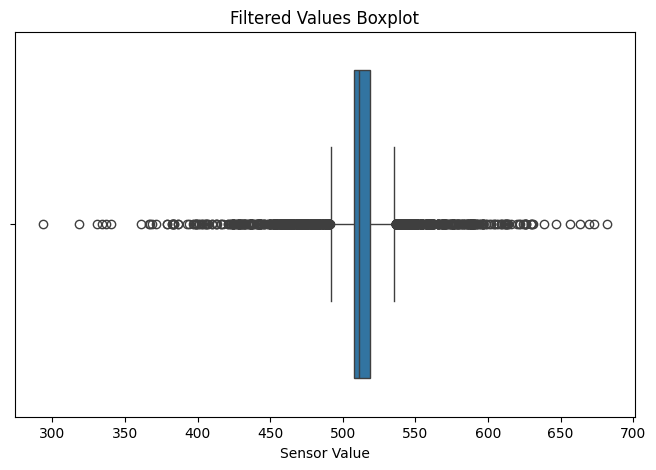

In [ ]:
# flatten using explode()
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['filtered_values'].explode().astype(float))

plt.title('Filtered Values Boxplot')
plt.xlabel('Sensor Value')
plt.show()

Envelope Column

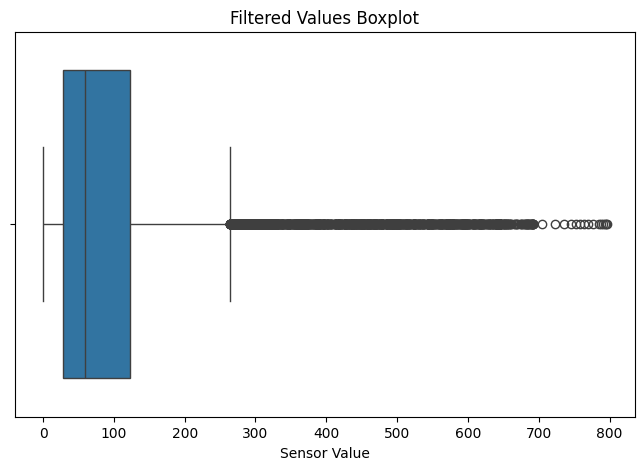

In [ ]:
# flatten using explode()
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['envelope_values'].explode().astype(float))

plt.title('Filtered Values Boxplot')
plt.xlabel('Sensor Value')
plt.show()

##### Level by level

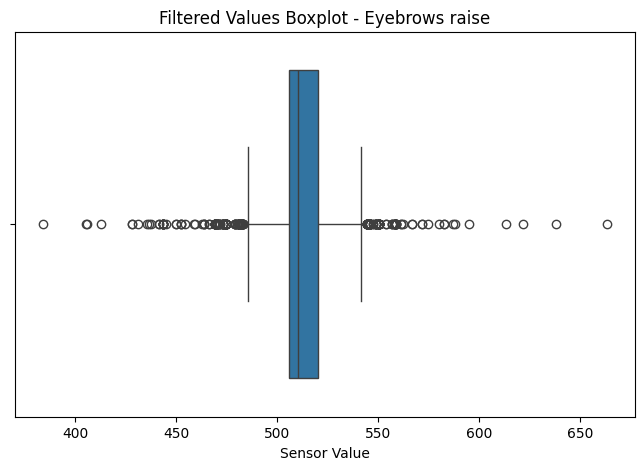

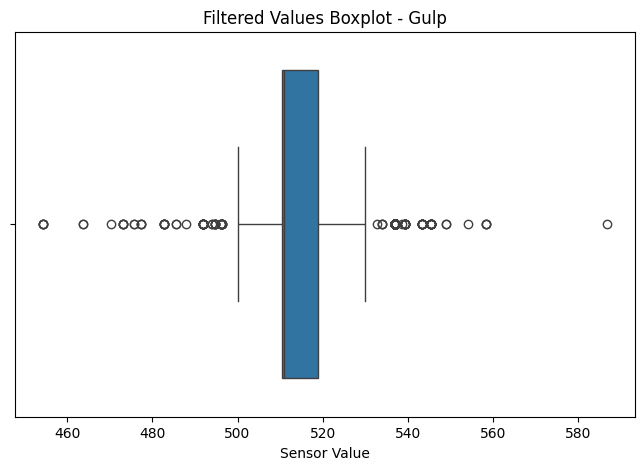

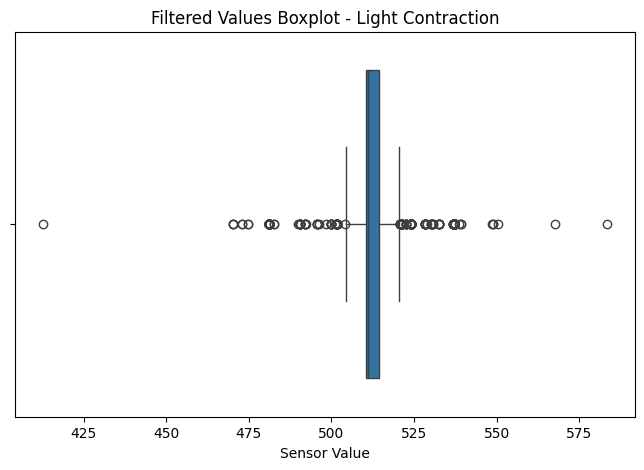

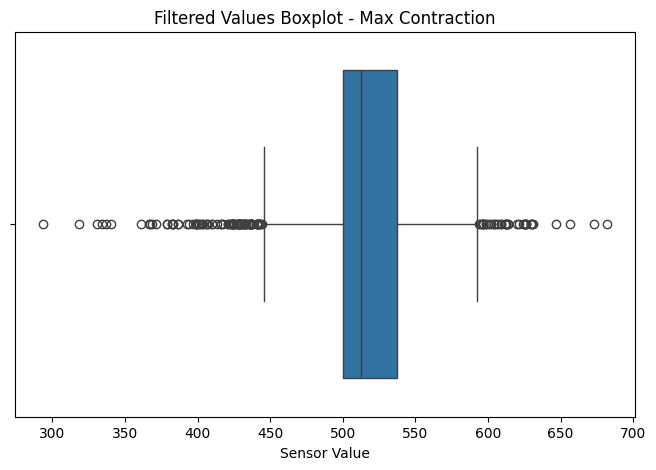

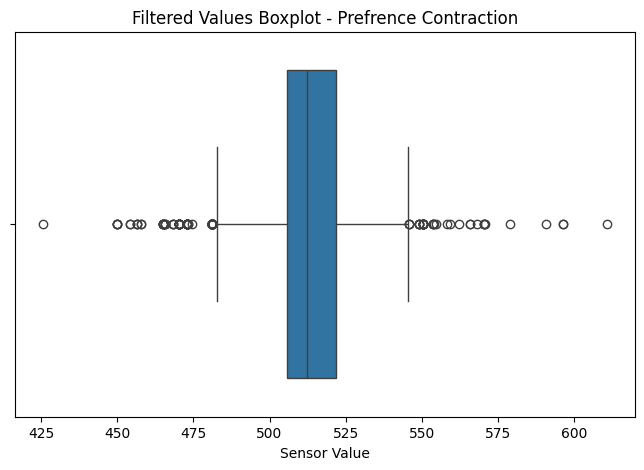

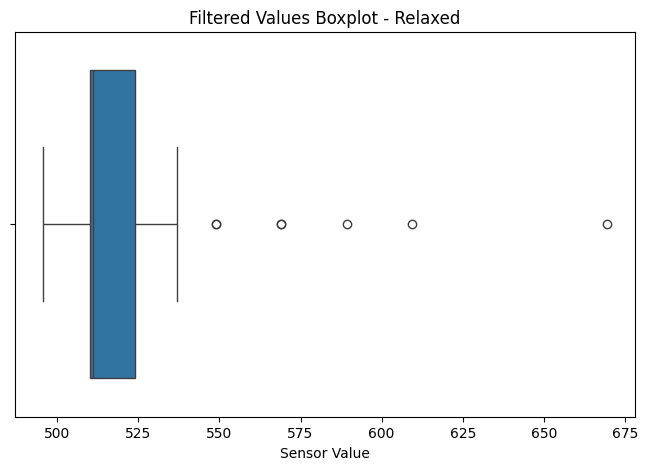

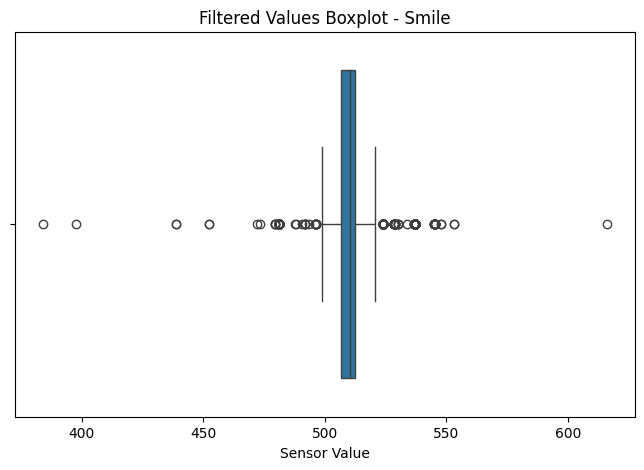

In [ ]:
for level, df in level_groups.items():
    plt.figure(figsize=(8, 5))
    # Explode the list of values and convert to float for plotting
    sns.boxplot(x=df['filtered_values'].explode().astype(float))
    plt.title(f'Filtered Values Boxplot - {level}')
    plt.xlabel('Sensor Value')
    plt.show()

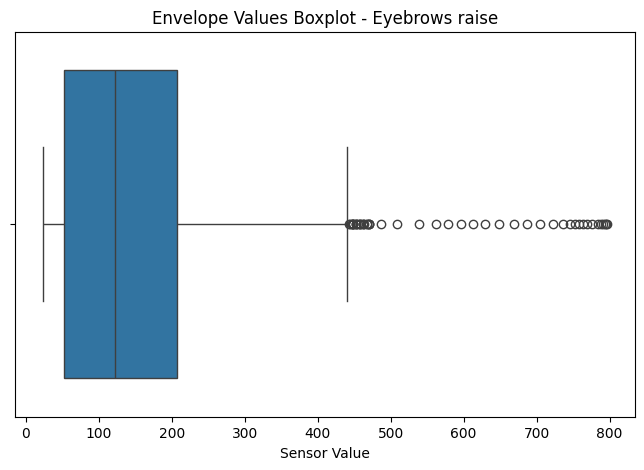

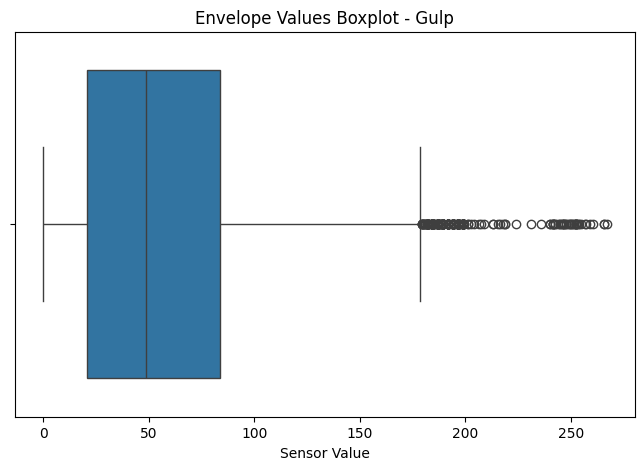

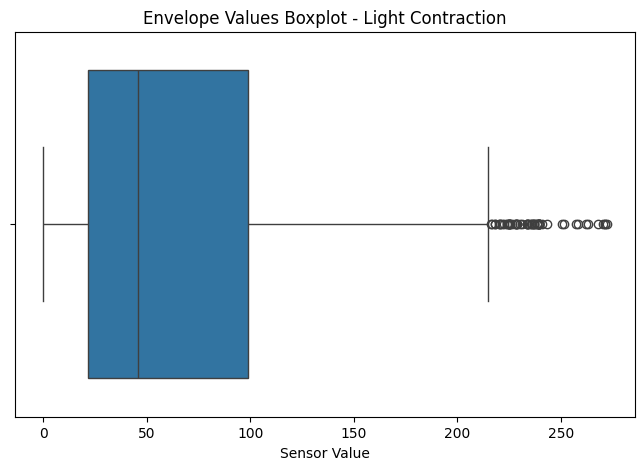

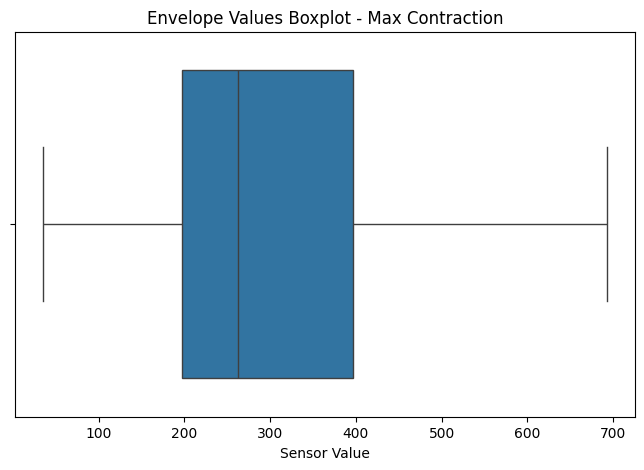

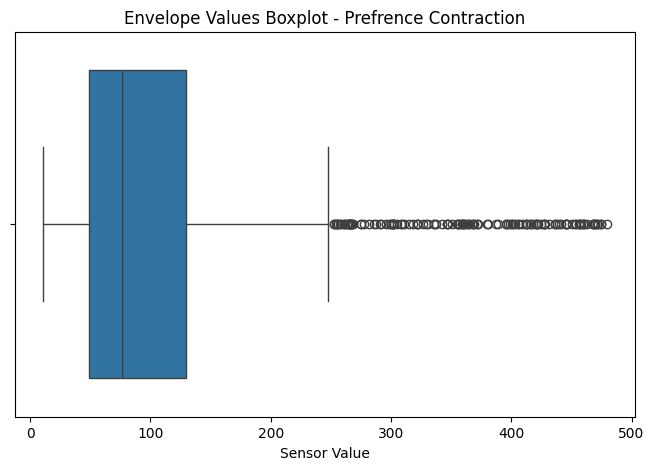

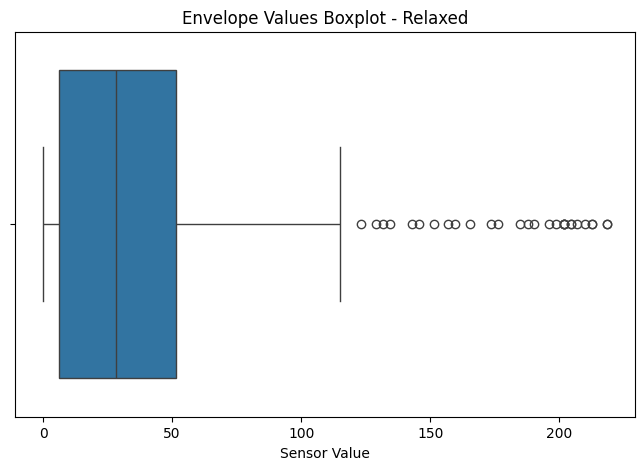

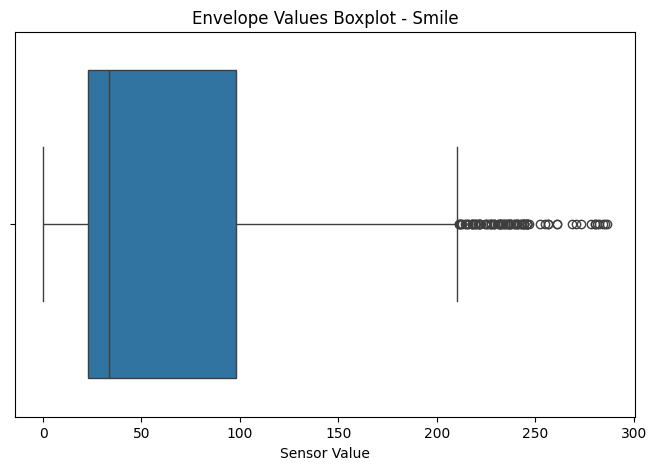

In [ ]:
for level, df in level_groups.items():
    plt.figure(figsize=(8, 5))
    # Explode the list of values and convert to float for plotting
    sns.boxplot(x=df['envelope_values'].explode().astype(float))
    plt.title(f'Envelope Values Boxplot - {level}')
    plt.xlabel('Sensor Value')
    plt.show()

#### Outliers - Histogram

##### All values

Filtered Column

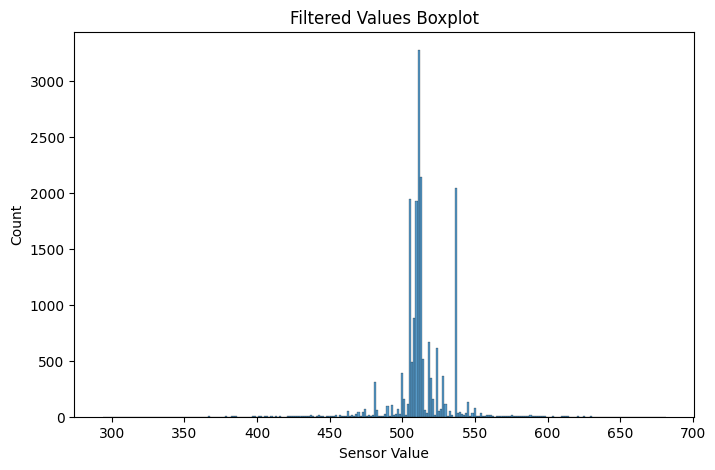

In [ ]:
# flatten using explode()
plt.figure(figsize=(8, 5))
sns.histplot(x=data['filtered_values'].explode().astype(float))
plt.title('Filtered Values Boxplot')
plt.xlabel('Sensor Value')
plt.show()

Envelope Column

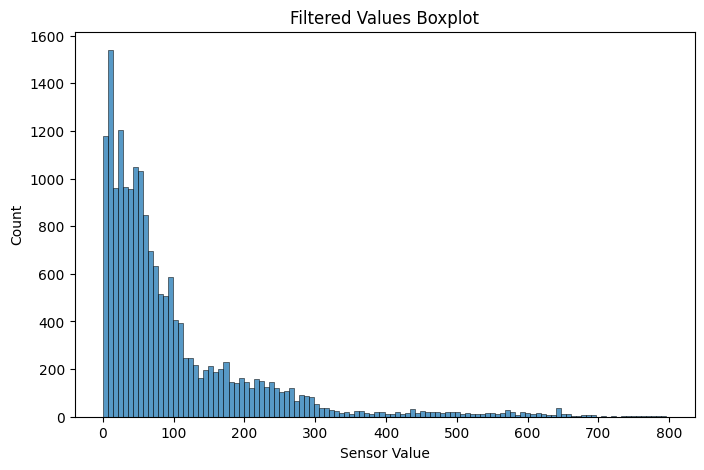

In [ ]:
# flatten using explode()
plt.figure(figsize=(8, 5))
sns.histplot(x=data['envelope_values'].explode().astype(float))

plt.title('Filtered Values Boxplot')
plt.xlabel('Sensor Value')
plt.show()

##### Level by level

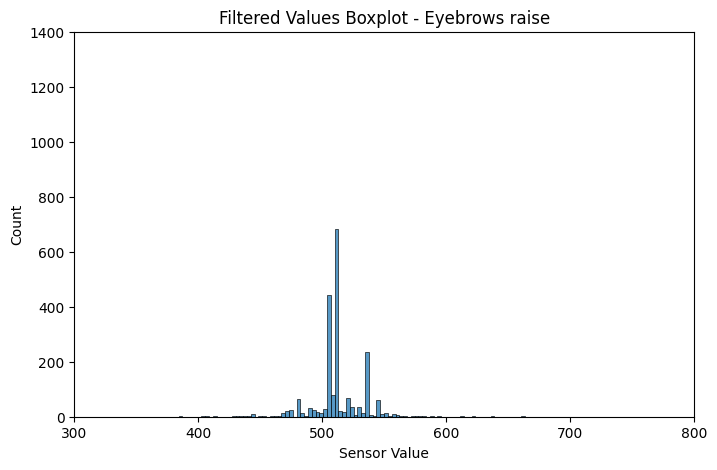

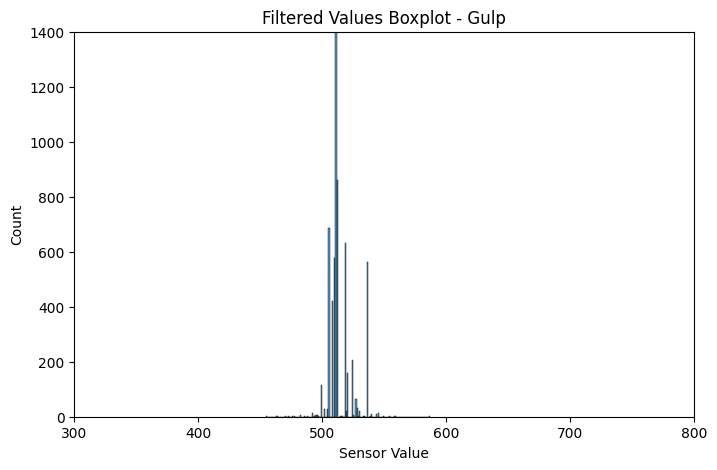

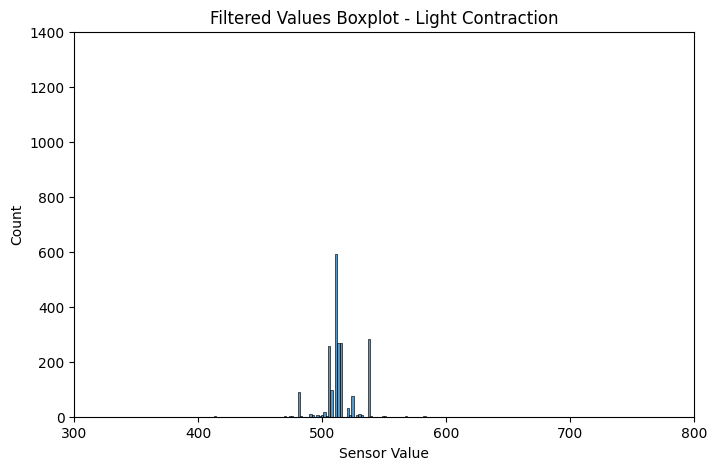

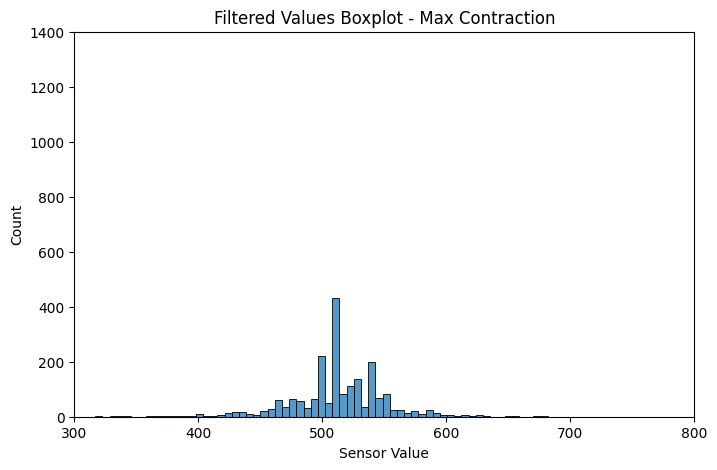

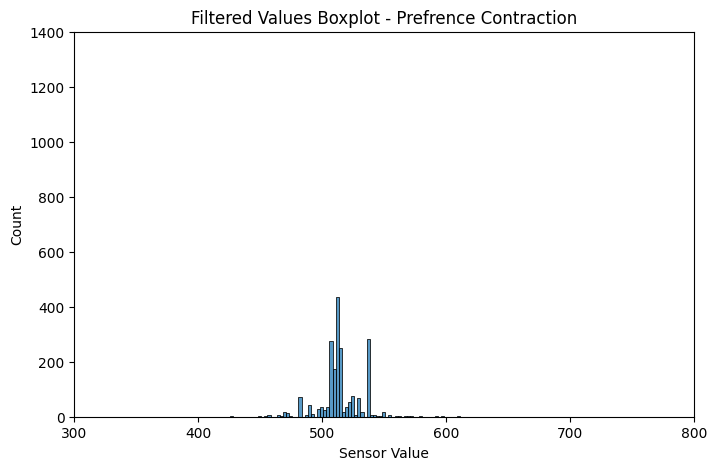

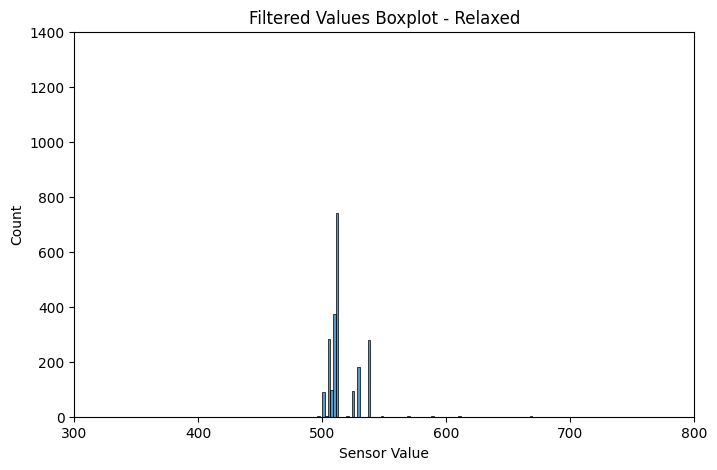

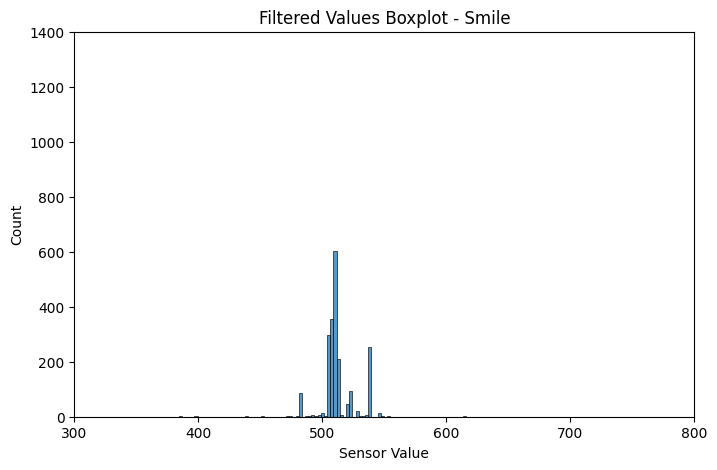

In [ ]:
for level, df in level_groups.items():
    plt.figure(figsize=(8, 5))
    # Explode the list of values and convert to float for plotting
    sns.histplot(x=df['filtered_values'].explode().astype(float))
    plt.title(f'Filtered Values Boxplot - {level}')
    plt.xlabel('Sensor Value')
    plt.xlim(300, 800)
    plt.ylim(0, 1400)
    plt.show()

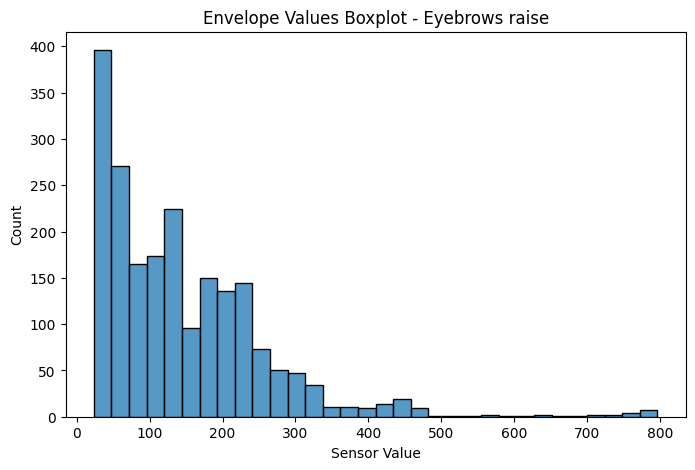

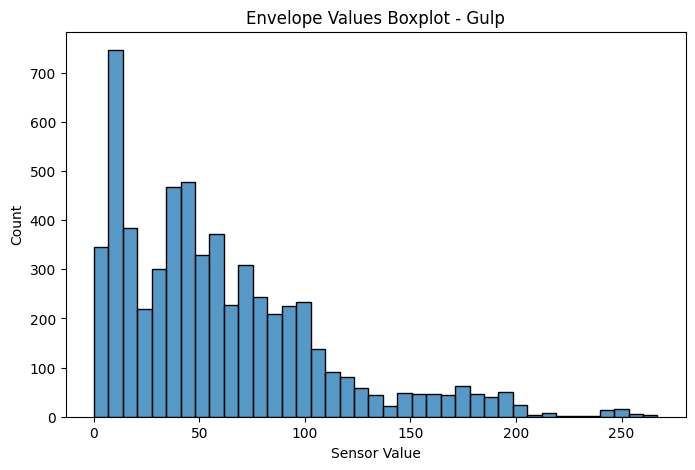

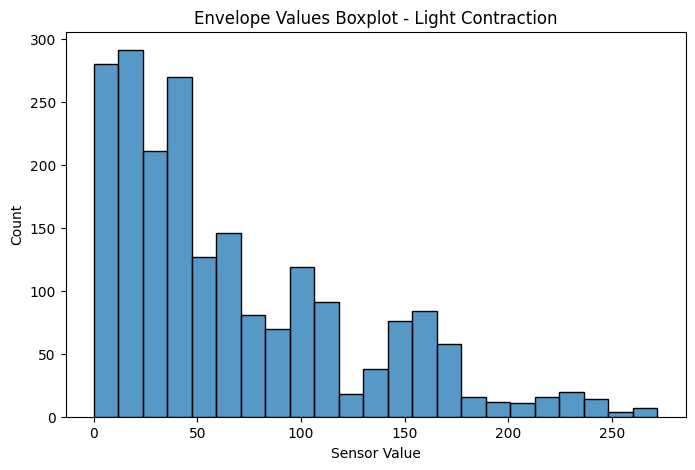

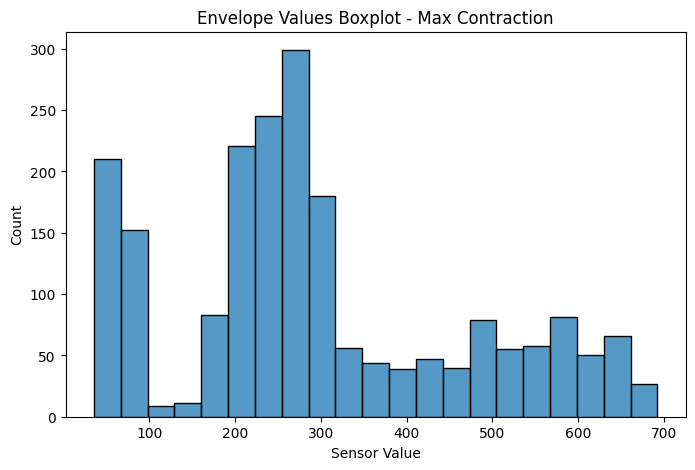

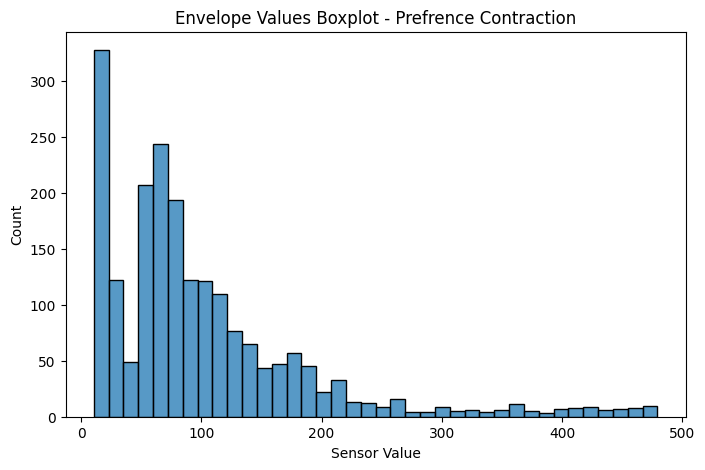

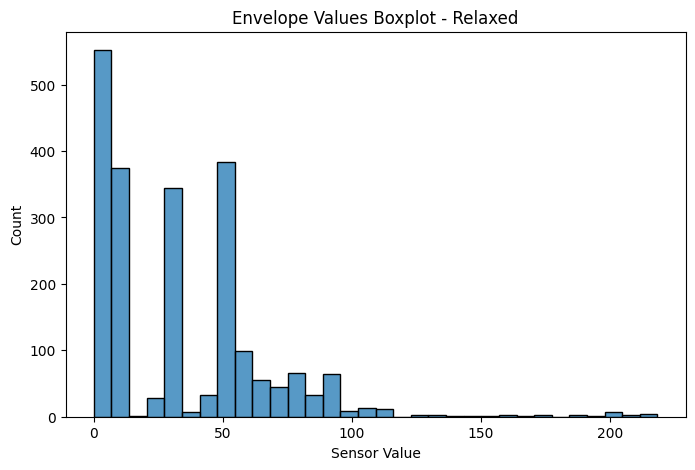

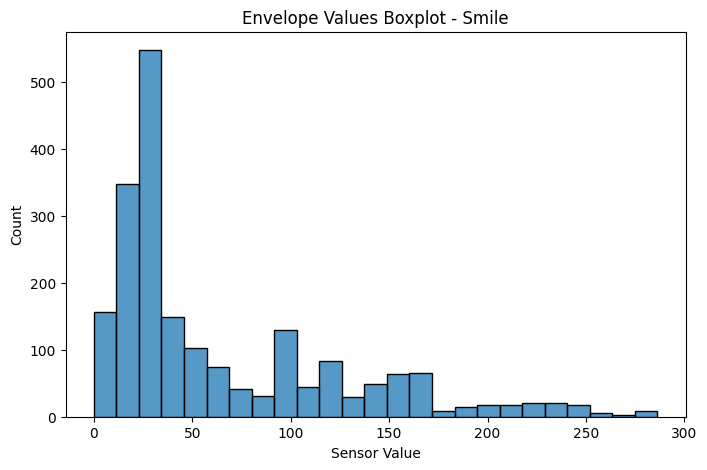

In [ ]:
for level, df in level_groups.items():
    plt.figure(figsize=(8, 5))
    # Explode the list of values and convert to float for plotting
    sns.histplot(x=df['envelope_values'].explode().astype(float))
    plt.title(f'Envelope Values Boxplot - {level}')
    plt.xlabel('Sensor Value')
    plt.show()